# Chapter 2   

# Review of Numerical Linear Algebra 
## Using Numpy and Pandas   

## Introduction

Data manipulation and numerical linear algebra are core skills for anyone performing computational statistics. Not only that, but this background is essential for you as your study of the rest of this book. Thus, this topic is a natural starting point.        

In this chapter we will first review numerical linear algebra using the Python NumPy package. We will explore some basics of linear algebra, the algebra of arrays. Our exploration will incldue basic algebraic manipulation of arrays and the often confusing topic of eigen decomposition. The focus, is on the use of the Numpy package for numerical linear algebra. There are many excellent texts which treat linear algebra in depth, including @Strang and @Lay. Those interested in an in-depth discussion of numerical algorithms for linear algebra can consult @GolubVanLoan.  

Second, this chapter introduces the basics of data manipulation with the both the Pandas data frame package and NumPy. Even though data manipulation is not the subject of this book, we will be using Numpy and Pandas throughout this book for data manipulaiton, often reffered to by data scientists as 'data munging'. @McKinney presents a broad overview of data manipulation and management using Pandas and NumPy.    

## Linear Algebra and NumPy

In this section we will review basic computational linear algebra. An understanding of computational linear algebra is essential to practicing computational statistics. Our focus will be numerical computing with the NumPy package Numpy.

In this book we only review the basics of linear algebra with NumPy. You can find more details in the NumPy tutorial.

Programming Note: NumPy is widely used for compuational statistics. NumPy computations are generally optimized. However, NumPy does not take full advantage of today's massively parallel cluster computing. Consequently, platforms like Spark [@Spark], TensorFlow [@tensorflow2015], and Torch [@paszke2017] take full advantage of today's massive scale custer computing environments. We do not address use of these platforms in this book. However, the principles of numerical linear algebra are the same.

## Types of Arrays

Linear algebra is the algebra of arrays. An array is a regular arrangement of numbers. An array can have any number of dimensions, at least in principle. The type of an array is not only defined by shape but also data type. In this discussion we focus on arrays of floating point numbers. 

A single numeric value is a **scalar**. A scalar has dimensional of 0.  

A **vector** is a one dimensional array. As an example a vector of length n, and the $ith$ value or element expressed as $x_i$, is written, $\mathbf{x} = [x_1, x_2, \ldots, x_n ]$. We can also express a **column** vector:   

$$
\mathbf{X} =
\begin{bmatrix}
   x_{1} \\
   x_{2} \\
   \vdots \\
   x_{n}
   \end{bmatrix}
$$

A **matrix** is a 2 dimensional array. As an example, consider a matrix with dimension $n$ rows by $m$ columns, $\mathbf{A}$. An element of this matrix for the $ith$ row and $jth$ column can be written, $x_{i,j}$. In general, this matrix can be expressed:  



$$
\mathbf{A} =
\begin{bmatrix}
   a_{1,1} & a_{1,2} & \ldots & a_{1,m} \\
   a_{2,1} & a_{2,2} & \ldots & a_{2,m} \\
   \vdots & \vdots & \ddots & \vdots \\
   a_{n,1} & a_{n,2} & \ldots & a_{n,m}
   \end{bmatrix}
$$

As has already been mentioned, arrays can have any number of dimensions. We will focus on vectors and matrices, as these are used most often in computational statistics.  


## Element-Wise Operations

We will start with simple element-wise arithmetic operations which can be performed on arrays. These operations include addition, subtraction, and multiplication. Elementwise operations have a **local effect** only, with the result determined by each paired set of values.   

Element-wise operations require both arrays to be **conformable**. By conformable arrays we mean arrays which have dimensions that conform to the shape required for the operation being performed. For element-wise operations, conformable arrays must have the exactly the same dimensions so that each element in each array has a corresponding element in the other array. There is an exception, when one array is a scalar, therefore having dimension 0.      

As a first step we will start an example by creating two vectors of length 3. In the code below, the NumPy [array](https://docs.scipy.org/doc/numpy/reference/generated/numpy.array.html) function is used to create these vectors. The vector is printed along with its type.


In [78]:
import pandas as pd
import numpy as np
import numpy.random as nr
import numpy.linalg as npla
import io
import requests
from math import sqrt, acos
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

y = np.array([2]*3)
print('Array y = {}, with type {}'.format(y,type(y)))
x = np.arange(1, 4)
print('Array x = {} with type {}'.format(x,type(x)))

Array y = [2 2 2], with type <class 'numpy.ndarray'>
Array x = [1 2 3] with type <class 'numpy.ndarray'>


We can perform element-wise operations on these array with a scalar. Some examples are shown below. Notice that the usual Python arithmetic operators are used for element-wise operations. 


In [79]:
a_scalar = 1.0
print(a_scalar + y)
print(a_scalar - x)

[3. 3. 3.]
[ 0. -1. -2.]


As further examples, the code below applies some element-wise operations to the arrays. 

In [80]:
print(y + x)
print(y - x)
print(y * x)

[3 4 5]
[ 1  0 -1]
[2 4 6]


We can also perform element-wise operations on matrices. The code below creates a 4x3 (four rows x three columns) array all with the same value, 2.0, using the NumPy [full](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.full.html) function and prints the result.  

In [81]:
A = np.full((4,3), 2.0)
print('A = \n{}'.format(A))

A = 
[[2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]]


Notice how this array is displayed. The rows are shown in order from the first row to the last. The values of each column for each row are shown within the row vectors. This is an important property of NumPy arrays, known as **row major order**. Other programming languages may use the alternative column major order. 

The code below creates another 4x3 array containing a sequence of numbers from 1 to 12, with the following steps: 
1. The NumPy [arange](https://docs.scipy.org/doc/numpy/reference/generated/numpy.arange.html) function creates a 1-dimensional 1x12 array (vector) of the values.
2. The shape attribute is changed to 4x3 using the [reshape](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html) method.  
3. The `shape` attribute is then accessed and printed. Notice there is a difference between changing the shape attribute with the `reshape` function and accessing the shape attribute of the array.  

In [82]:
B = np.arange(1,13).reshape((4,3))
print('Matrix B with shape {} \n{}'.format(B.shape, B))

Matrix B with shape (4, 3) 
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


We can add a scalar to the matrix as shown in the code below. 

In [83]:
print('{} + A = \n{}'.format(a_scalar, a_scalar + A))

1.0 + A = 
[[3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]]


And, we can add the two conformable arrays as shown in the code below. 

In [84]:
print('A + B = \n{}'.format(A + B))

A + B = 
[[ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]
 [12. 13. 14.]]


> **Exercise 02-1:** In the foregoing code example two conformal matrices are summed element-wise. Now, you will create conformable matrix with all the elements with a value of 4.0. Then, multiply this matrix by the matrix B. Check that your result is correct. 

In [85]:
C = np.full((4,3),4.0)
print(C)
print(B+C)



[[4. 4. 4.]
 [4. 4. 4.]
 [4. 4. 4.]
 [4. 4. 4.]]
[[ 5.  6.  7.]
 [ 8.  9. 10.]
 [11. 12. 13.]
 [14. 15. 16.]]


## The Dot Product, A Fundamental Array Operation

After the foregoing introduction to the element-wise operations we move on to other array operations. We will start with perhaps the most fundamental multi-element operations, the **inner product** also known as the **dot product** or **scalar project**. Many other linear algebra calculations can be constructed using the dot product. If your software can do dot projects efficiently many other operations can be performed efficiently. This observation is the basis of many scalable machine learning platforms such as Torch, TensorFlow and SPARC.    

The dot product between two vectors is defined as follows an is denoted as wither $a \cdot b$ or $<a,b>$: 

$$
dot\ product = a \cdot b =\ <a,b>\ = \Sigma_i^n a_i \cdot b_i 
$$

A useful property is that the **Euclidian norm** (length), or **L2 norm**, of a vector is the square root of the dot product with itself. This can be expressed:

$$
\parallel a \parallel = length\ of\ vector\ a = \sqrt{a \cdot a}
$$

But, how can you interpret the dot product? The dot product is the **projection** of one vector on another. This concept can be expressed mathematically:   

$$
a \cdot b = \parallel a \parallel \parallel b \parallel cos(\theta)
$$

Rearranging terms we can find the **cosine distance** between two vectors as: 

$$
cos(\theta) = \frac{a \cdot b}{\parallel a \parallel \parallel b \parallel}
$$

Notice that the dot product of orthogonal (perpendicular) vectors is $0$. In this case there is no projection of either vector on the other. Whereas, for parallel vectors the dot product is at a maximum.    

These concepts are illustrated in the figure below. The dot product is the projection of one vector on another. The angle between the two vectors, $\theta$, determines the projection. You can see that if $\theta = \frac{\pi}{2}$ the projection will be 0. If $\theta = 0$ the projection is maximized.  

<img src="../images/DotProduct.png" alt="Drawing" style="width: 400px;"/>

The code in the cell below computes the dot product of the two vectors, a and b using the NumPy [dot](https://docs.scipy.org/doc/numpy/reference/generated/numpy.dot.html) function. 


In [86]:
print('For vectors')
print('x = {}'.format(x))
print('y = {}'.format(y))
np.dot(x,y)  
print('<x,y> = {}'.format(np.dot(x,y)))

For vectors
x = [1 2 3]
y = [2 2 2]
<x,y> = 12


The result is the expected 12 = 2 + 4 + 6.  

As has been mentioned, the dot product is the projection of one vector on another. The code below demonstrates this point by taking the dot product of a vector with 3 times the same vector. 

In [87]:
np.dot(y, np.dot(3,y))

np.int64(36)

This dot project is 3 times the dot product of $y$ with itself. Demonstrating that the projection scales with the length of the vectors.    

**Orthogonal vectors** should have a dot product of 0. Intuitively, orthogonal vectors have no common directions. This useful property can be used to the test if vectors are orthogonal. This concept is demonstrated by the code below which takes the dot product of two orthogonal vectors.  

In [88]:
w = np.array([1.0,1.0,0.0])
z = np.array([0.0,0.0,1.0])
np.dot(w, z)

np.float64(0.0)

The result is 0, as expected. 

As already stated, dot or inner product can be used to compute the L2 norm of a vector. The code below uses the [`norm`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.norm.html) function from the [`numpy.linalg`](https://docs.scipy.org/doc/numpy/reference/routines.linalg.html) package to compute the norm of a vector. 

In [89]:
npla.norm(y) 

np.float64(3.4641016151377544)

> **Exercise 02-2:** In the cell below create and excute the code to computes the cosign of the angle between the vectors x and y. 

In [90]:
## Put your code below  
cos = np.dot(x,y)/(np.linalg.norm(x) * np.linalg.norm(y))
print(cos)

0.9258200997725515


## The matrix transpose

In many cases, we need the **transpose** of a matrix. The transpose is found by interchanging the row and column indices of a matrix.   

Consider a 1-dimension vector of dimension $1 x n$. The transpose of this array is a column vector of dimension $n x 1$. 

The elements of a 2-dimensional matrix are indexed first by a row index and then a column index, or $A_{i,j}$. The transpose is then, $A_{j,i}$, with the indices reversed. For example, using the notation #B^T# for the transpose, we can write:

$$
B_{ji} = B_{ij}^T
$$

where,   
$B$ has dimensions n x m.   
$B^T$ has dimensions m x n. 

To illustrate this idea, the code below uses the NumPy [transpose]() function to find the transpose of a matrix. 


In [91]:
np.transpose(B)

array([[ 1,  4,  7, 10],
       [ 2,  5,  8, 11],
       [ 3,  6,  9, 12]])

## The matrix product

Can we take other products of arrays? The answer is yes. We can multiply a vector times a matrix, or a matrix times a matrix. As you will see all of these operations are built with dot products. This is why the dot product is so important in computational statistics.   

To start, consider how to compute the product of a matrix and a vector. You can think of this operation as a series of dot products between the rows of the matrix and the column vector. More specifically, an $m x n$ matrix, $\mathbf{A}$, is multiplied by a vector, $\mathbf{x}$, of length $m$ by taking the $n$ dot products. The result is a vector of length $n$. This concept is illustrated in the relationship below. 

$$
\begin{bmatrix}
   a_{1,1} & a_{1,2} & \ldots & a_{1,m} \\
   a_{2,1} & a_{2,2} & \ldots & a_{2,m} \\
   \vdots & \vdots & \ddots & \vdots \\
   a_{n,1} & a_{n,2} & \ldots & a_{n,m}
   \end{bmatrix}
\begin{bmatrix}
   x_{1} \\
   x_{2} \\
   \vdots \\
   x_{n}
   \end{bmatrix} = 
\begin{bmatrix}
   \mathbf{A}_{row\ 1} \cdot \mathbf{x} \\
   \mathbf{A}_{row\ 2} \cdot \mathbf{x} \\
   \vdots \\
   \mathbf{A}_{row\ n} \cdot \mathbf{x}
   \end{bmatrix}   =
\begin{bmatrix}
   y_1 \\
   y_2 \\
   \vdots \\
   y_n
   \end{bmatrix}   
$$

We can summarize the above for the $ith$ element of the resulting vector as:

$$
y_i = \Sigma_j^m A_{ij} \cdot x_j
$$


To demonstrate this concept, the code in the cell below uses the NumPy `dot` function to compute the product of a matrix and a vector.  


In [92]:
print(B.shape)
print(x.shape)
np.dot(B, x)

(4, 3)
(3,)


array([14, 32, 50, 68])

How do we extend the above computation to compute the product of two matrices? The answer is simple and intuitive. Each element of the result is the dot product between a row of the first matrix and a column of the second matrix. This is known as the row by column or **RC rule**. The product of an $n x m$ matrix with an $m x n$ matrix is an $m x m$ dimensional array, computed by taking $m^2$ dot products. For example, the element $Y_{ij}$ of the result matrix is computed as follows:

$$
Y_{ij} = \Sigma_j^m A_{ij} \cdot B_{ji}
$$

Notice that to be conformable the number of columns, $m$, of the first matrix must equal the number of rows of second matrix. And, that the number of rows, $n$ of the first matrix must equal the number of columns of the second matrix.

The code in the cell below computes a matrix product. As both matrices are of dimension $4x3$, it is necessary to take the transpose of one or the other.  

> **Programming Note:** For this example, we could use the Numpy `dot` function. However, here we use the [`matmul`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.matmul.html#numpy.matmul) function. For 1 and 2 dimensional arrays, the results will be the same. But, `matmul` works with arrays of higher dimenstions, but not with scalars. The arrays must be conformable for either function to work.

In [93]:
np.matmul(np.transpose(A) , B)

array([[44., 52., 60.],
       [44., 52., 60.],
       [44., 52., 60.]])

The above operation resulted in a $3 x 3$ matrix. Taking the transpose of the second matrix results in a conformable operation, but the result will have different dimensions. 

In [94]:
np.matmul(A, np.transpose(B))

array([[12., 30., 48., 66.],
       [12., 30., 48., 66.],
       [12., 30., 48., 66.],
       [12., 30., 48., 66.]])

Now, the product is a $4 x 4$ matrix. 

> **Programming Note:** In the foregoing you have seen how matrix products are built from dot products. If the dot product can be computed efficiently, then so to can matrix products be computed efficiently. Not only that, but each of the dot products required for these operations can be computed in parallel, as there is no dependency of one on another. These properties are at the basis of many of today's high performance computing environments used for machine learning and AI.   


> **Exercise 02-3:** Perhaps, you are curious about what happens if you try to multiply non-conformable arrays. To find out, multiply the matrix A by the matrix B, but without the transpose. 

In [95]:
A@B

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 3)

> Why is there a mismatch in the dimensions when attempting to compute this matrix product? 

> **Answer:** 

## The identity matrix and the inverse

Is it possible to divide one matrix by another? Yes in a certain way, but not in a direct manner. Instead, this operation is performed by finding the **inverse** of a matrix and multiplying by that inverse by the other matrix.   

Before explaining the inverse, we need to examine a matrix with special properties, the **identity matrix**. An identity matrix is a square $n x n$ matrix with 1s on the diagonal and 0s everywhere else. We can write the identity matrix as follows:


$$
I = \begin{bmatrix}
    1  & 0 & 0 & \dots & 0 \\
    0  & 1 & 0 & \dots & 0 \\
    0  & 0 & 1 & \dots & 0 \\
    \vdots &\vdots &\vdots & \ddots & \vdots \\
    0 & 0 & 0 & \dots & 1
\end{bmatrix}
$$


The code in the cell below creates a $3 x 3$ identity matrix using the NumPy [eye](https://docs.scipy.org/doc/numpy/reference/generated/numpy.eye.html) function. 


In [ ]:
I3 = np.eye(3)
I3

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

hat will be the result if we multiply the identity by another square matrix? To understand the result, consider that multiplying by an identity matrix in linear algebra is the same as multiplying by a 1 in ordinary algebra.   

The identity multiplied by any matrix gives that same matrix. If $A$ is a square matrix (conformable) then:

$$
A = I \cdot A = A \cdot I
$$

Let's illustrate this concept with an example. First, the code in the cell below creates a $3 x 3$ numeric matrix.  

In [ ]:
C = np.array([[1,3,6],
              [2,2,1],
              [3,1,4]])
print('C = \n{}'.format(C))

C = 
[[1 3 6]
 [2 2 1]
 [3 1 4]]


Now, we compute the product of the above matrix with the identity matrix 

In [ ]:
print('C I3 = \n{}'.format(np.dot(C,I3)))
print('I3 C = \n{}'.format(np.dot(I3, C)))

C I3 = 
[[1. 3. 6.]
 [2. 2. 1.]
 [3. 1. 4.]]
I3 C = 
[[1. 3. 6.]
 [2. 2. 1.]
 [3. 1. 4.]]


The result is the same as the original matrix. This example demonstrates that multiplying a square matrix by an identity matrix of the same dimension is the same as multiplying by 1 in regular algebra. 

Let's get back to the inverse of a matrix. In principle we can compute an inverse of a square matrix so that the following relationships hold:


\begin{align}
\begin{split}
A &= A\\
A &= AI \\
A^{-1}A &= I
\end{split}
\end{align}

Here, $A^{-1}$ is the inverse of $A$.

To illustrate this concept the code in the cell below computes the inverse of the matrix using the [inv](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.inv.html) from the NumPy linalg package. The inverse is then multiplied by the original matrix. 




In [ ]:
inv_C = npla.inv(C)
print('inv_C = \n{}'.format(inv_C))
print('inv_C C = \n{}'.format(np.dot(inv_C,C)))

inv_C = 
[[-0.21875  0.1875   0.28125]
 [ 0.15625  0.4375  -0.34375]
 [ 0.125   -0.25     0.125  ]]
inv_C C = 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


The result is an identity matrix, as it should be. 

> **Exercise 02-4:** The identity matrix has a special property, that it is its own inverse. To demonstate this property, create a $4x4$ identity matrix and take its inverse. Verity that the result the same.

In [ ]:
## Put your code below
idnt = np.eye(4)
print(idnt)
inv_idnt = np.linalg.inv(idnt)
print(inv_idnt)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Slicing NumPy arrays

When using NumPy, you will very often need a subset of an array for some operations. Fortunately, NumPy arrays are easy to subset, an operation known as [**slicing** or **indexing**](https://docs.scipy.org/doc/numpy/reference/arrays.indexing.html). For a NumPy array, the slicing operator are the square brackets, `[]`. For a 2-dimensional matrix the syntax for this operator is:

$$
slice = array[row\_start:row\_end,\ column\_start,column\_end]
$$

Where, keeping in mind that NumPy indices are zero based,     
$row\_start =$ the index of the first row in the slice.     
$row\_start =$ the index of the first row not in the slice.    
$row\_start =$ the index of the first column in the slice.     
$row\_start =$ the index of the first column not in the slice.    

The figure below shows an example of slicing a 2-dimensional array, or matrix. The matrix has dimension $8 x 6$, and a slice of dimension $4 x 3$ is created. Notice the syntax of the row and column slices. 

<img src="../images/NumpySlice.png" alt="Drawing" style="width: 600px;"/>

There are some other ways to specify slices that use implied starts or ends, or a specific list of indices. 

| Required Operation | Syntax |
| --- | --- |
| All rows or all columns | `:` |     
| first n rows or columns | `:n`|   
| Rows or columns after the nth | `n:` |   
| All but the last n rows or columns | `:-n` |   
| Specific rows or columns | List of indices |       
| Specific rows or columns | List of logicals |      

To illustrate these operations, let's try some examples. The code below creates a slice of columns 1 and 2 a NumPy matrix, keeping all rows:  


In [ ]:
B[:, 1:3]

array([[ 2,  3],
       [ 5,  6],
       [ 8,  9],
       [11, 12]])

The code below creates a slice of the first 2 rows of a NumPy matrix, while keeping all columns. 

In [ ]:
B[:2, :]

array([[1, 2, 3],
       [4, 5, 6]])

And, the code below creates a slice with rows 0 and 2. Don't be confused by the two sets of square brackets, `[]`. The outer square brackets are the slicing operator whereas, the inner square brackets are for the list of row indices. 

In [ ]:
B[[0,2], :]

array([[1, 2, 3],
       [7, 8, 9]])

The same result can be achieved with a list of logical type, as shown here. 

In [ ]:
B[[True,False,True,False], :]

array([[1, 2, 3],
       [7, 8, 9]])

The results are the same for both of the above cases. 

> **Exercise 02-5:** In the foregoing discussion of the matrix inverse, we did not address an important and common problem. Simply put, matricies with colinear or parallel columns are said to be **singular**. The inverse of a singular matrix does not exist. You will now determine if the columns of a matrix are nearly colinear. In compuational linear algebra, nearly colinear columns will cause matrix inverse algorithms to fail. Dealing with this problem is a focus of Chapter 24 of this book. You will now complete the code below to do the following: 
> 1. First you will construct a nearly sigular $4 x 4$ matrix with sequential values 1 to 16 running row-wise. Name this matrix `E`.    
> 2. Next, using the indices createded by the Itertools [`combinations`](https://docs.python.org/2/library/itertools.html#itertools.combinations) function you will slice the array column-wise, for every possible pair of columns. Notice that you do not need to hard code the instantiation of the vector of possible column indicies.  
> 3. Compute the cosign of the angle between each of the column-wise slices. 
> 4. Print the indices and the cosign of the angle between them. 
> 5. Compute the inverse of the matrix and print the result.
> 6. Display the product of the matrix and the inverse computed.   


In [ ]:
## Put your code below   

E = np.arange(1,17).reshape((4,4))
print(E)
comb = combinations(range(E.shape[1]),2)
for c in comb:
    dp = np.dot(E[:,c[0]],E[:,c[1]])
    print(f"indices {c[0]}, {c[1]} cosign = {dp/(np.linalg.norm(E[:,c[0]])*np.linalg.norm(E[:,c[1]]))}")
inv_E = np.linalg.inv(E)
print(inv_E)
print(np.dot(inv_E,E))


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
indices 0, 1 cosign = 0.9982731812361942
indices 0, 2 cosign = 0.9942437282626196
indices 0, 3 cosign = 0.9890707100936805
indices 1, 2 cosign = 0.9988206152282789
indices 1, 3 cosign = 0.9960238411119947
indices 2, 3 cosign = 0.9991745768300444
[[-3.00645705e+15  4.74703745e+15 -4.74703745e+14 -1.26587665e+15]
 [ 3.92421762e+15 -7.12055617e+15  2.46845947e+15  7.27879075e+14]
 [ 1.17093590e+15 -0.00000000e+00 -3.51280771e+15  2.34187181e+15]
 [-2.08869648e+15  2.37351872e+15  1.51905198e+15 -1.80387423e+15]]
[[  5.75    4.5     9.25   12.   ]
 [ -5.875  -7.25  -10.625 -12.   ]
 [  2.      4.      2.      0.   ]
 [ -1.5    -1.     -0.5     0.   ]]


> Now, answer the following questions:    
> 1. What does the cosine of the angle between the vectors tell you about the colinearity of the columns of the matrix?    
> 2. Examine values of the inverse computed. What do these large values tell you about the stability of the inverse calculations?    
> 3. Examine the product of the matrix with its inverse. What does this result tell you about the invese?   

> **Answers:**     
> 1. that the vectors are not linearly independent       
> 2. the inverse valuea are huge       
> 3. the inverse does not exist, because the matrix is not full rank

## Copies of NumPy arrays

NumPy operations follow the same assignment rules as other Python operators. However, these assignment rules create pitfalls for newcomers. A simple `=` only assigns a new name to the same array. To ensure the ssignment creates a copy, one must use the [`copy`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.copy.html) function. This idea is illustrated in the code below. 

In [ ]:
C = np.copy(B)
B = B + 1.0
print('B = \n{}'.format(B))
print('C = \n{}'.format(C))

B = 
[[ 2.  3.  4.]
 [ 5.  6.  7.]
 [ 8.  9. 10.]
 [11. 12. 13.]]
C = 
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


These results are what we intended. Failure to use the `copy` function can result in unexpected and confusing errors. 

## Broadcasting for Numeric Linear Algebra

## Pandas, a Data Scientist's Friend

Now we will turn our attention to the Pandas package [@Pandas]. Pandas has become a standard tool in data scientists' tool kit for data management and manipulation. 

Pandas is an extension of NumPy's arrays. Pandas provides significant capabilities to mange and manipulate tabular data. The focus of this book is not on the data manipulation capabilities of Pandas, so only an overview is provided here. The [tutorials on the Pandas.org website](https://pandas.pydata.org/pandas-docs/stable/getting_started/index.html#getting-started) provide greater depth.      

### What is a data frame?

The basic Pandas data structure is the data frame. A data frame is a tabular data structure with a number of special attributes. The most important of these attributes are the row indices, column indices and data types of the columns. A schematic view of a Pandas data frame with these important attributes is illustrated in the figure below.   

<img src="../images/PandasDataFrame.png" alt="Drawing" style="width: 600px;"/>

As you can see from the above figure, the basic Pandas data frame is an $n x m$ table. The data are arranged in $m$ columns. Each column has an index, which can be a column name as a string, and a data type. Each column can have a different data type, but each column can only have one type. There is also a set of row $n$ indices. Row indices are typically numeric, in the range $\{0,n-1\}$, but can be names in the form of strings.   

An example will help illustrate these points. There are a number of ways to construct a Pandas data frame. Perhaps, the simplest is creating a data frame from an array, using the Pandas [DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) method, as is done here. 


In [ ]:
a_dataframe = pd.DataFrame([[1, 3, 5],
                            [2, 4, 8],
                            [10, 20, 30],
                            [15, 25, 35]])
a_dataframe  

,0,1,2
0,1,3,5
1,2,4,8
2,10,20,30
3,15,25,35


You can see that the data frame has integer column and row indices at this point. We can assign new values to these attributes, as shown in the code below. The `index` attribute changes the row indices and the `columns` attribute changes the column names.   

In [ ]:
a_dataframe.index = ['first_row','second_row','third_row','forth_row']
a_dataframe.columns = ['first_col','second_col','third_col']
a_dataframe

,first_col,second_col,third_col
first_row,1,3,5
second_row,2,4,8
third_row,10,20,30
forth_row,15,25,35


Let's add another column to this data frame. This can be done using the [`loc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) method. The `loc` method allows you to specify the rows as the first argument and the columns as the second argument. A colon, `:` indicates all rows or all columns. The code below adds a new column named 'animal'. 

In [ ]:
a_dataframe.loc[:,'animal'] = ['chicken','chicken','duck','duck']
a_dataframe

,first_col,second_col,third_col,animal
first_row,1,3,5,chicken
second_row,2,4,8,chicken
third_row,10,20,30,duck
forth_row,15,25,35,duck


Let's have a look at the type attributes of the columns, the `dtypes`.

In [ ]:
a_dataframe.dtypes

first_col     int64
second_col    int64
third_col     int64
animal          str
dtype: object

The first three columns are integer type. With Pandas, the type of a string column is shown as `object`.

It is possible to change the data types of columns. In the code below we will change the type of the third column to floating point, using the `flaot64` type from NumPy. The string column is coerced to categorical. 

In [ ]:
a_dataframe.loc[:,'animal'] = a_dataframe.loc[:,'animal'].astype('category')
a_dataframe.loc[:,'third_col'] = a_dataframe.loc[:,'third_col'].astype(np.float64)
#a_dataframe["third_col"] = a_dataframe["third_col"].astype(np.float64)
a_dataframe.dtypes

first_col       int64
second_col      int64
third_col     float64
animal            str
dtype: object

Notice the new dtypes of the last two columns. 

### Slicing Pandas Data Frames

Just as we did for NumPy arrays, [Pandas data frame can be sliced](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html). There are a number of ways to define slices for Pandas data frame. Here we will focus on the computationally efficient [`loc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) and [`iloc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html) methods. You have already seen an example of using `loc` above. 

The `iloc` method slices using row and column indices, hence the 'i'. The rules and syntax are essentially identical to those used for slicing NumPy arrays, which we have already discussed. 

The `loc` method performs slicing operations on Pandas data frames using column or row names, as well as logical selection. The syntax and rules are similar to NumPy array slicing. For example, the code below creates a slice with the columns up to and including `third_col`.    


In [ ]:
a_dataframe.loc[:,:'third_col']

,first_col,second_col,third_col
first_row,1,3,5.0
second_row,2,4,8.0
third_row,10,20,30.0
forth_row,15,25,35.0


As another example, the code below creates a slice starting with `second_col` and ending with, and including, `third_col`.    

In [96]:
a_dataframe.loc[:,'second_col':'third_col']

,second_col,third_col
first_row,3,5.0
second_row,4,8.0
third_row,20,30.0
forth_row,25,35.0


The `loc` method can be used to find a slice of a data frame including the columns in a list, as shown here. 

In [97]:
a_dataframe.loc[:,['second_col','animal']]

,second_col,animal
first_row,3,chicken
second_row,4,chicken
third_row,20,duck
forth_row,25,duck


Finally, a logical operation can be used to for slicing, as shown below. In this case, the `loc` method is used twice. Once for the slicing the data frame and once for the logical operator.    

In [98]:
a_dataframe.loc[a_dataframe.loc[:,'animal']=='duck',:'third_col']

,first_col,second_col,third_col
third_row,10,20,30.0
forth_row,15,25,35.0


### Copies of Pandas data frames

Just like NumPy operations, Pandas operations follow the same assignment rules as other Python operators.  An `=` operator only assigns a new name to the same array. Further,  the `loc` and `iloc` methods only create references, they do not return copies. This behavior optimizes memory use for scalability. If you want to ensure you have actually made a copy use the [`copy`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.copy.html) method.     

This idea is illustrated in the code below which performs the following steps:
1. A slice is assigned to a new name. 
2. A slice is created and copied and assigned to another name. 
3. A A constant is added to the first slice using the Pandas [`add`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.add.html) method.
4. The values for each name are printed. 

> **Programming Note:** Notice there are two methods in the second line of code, This is an example of **chaining operators**. Chaining operators is a powerful approach for computational statistics. We will chain operators many times in the remainder of this book.   


In [101]:
another_dataframe = a_dataframe.loc[a_dataframe.loc[:,'animal']=='duck',:'third_col']
copy_dataframe = a_dataframe.loc[a_dataframe.loc[:,'animal']=='duck',:'third_col'].copy()
another_dataframe = another_dataframe.add(1.0)
print(another_dataframe)
print(copy_dataframe)
print(a_dataframe)

           first_col  second_col  third_col
third_row       11.0        21.0       31.0
forth_row       16.0        26.0       36.0
           first_col  second_col  third_col
third_row         10          20       30.0
forth_row         15          25       35.0
            first_col  second_col  third_col   animal
first_row           1           3        5.0  chicken
second_row          2           4        8.0  chicken
third_row          10          20       30.0     duck
forth_row          15          25       35.0     duck


Notice the difference in these results. A copy is not the same as a slice of the original data frame.

### The Pandas series

We have been working with the 2-dimensional Pandas data frames. There is a special case for univariate data, the [Pandas series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html). This distinction is important. Panads series have different attributes from data frames. This means different methods are applicable. Failure to abide by this distinction will often produce unexpected results or raise exceptions.   

The code below creates a single column slice from a data frame. The result is Pandas series. 


In [104]:
a_series = a_dataframe.loc[:,'second_col'].copy()
type(a_series)

pandas.Series

A noticeable difference for this series is that there is no column name attribute. Since a Pandas series has only one column, there is no need for this attribute.  

> **Exercise 02-6:** A limited number of mathematical operatons can be performed directly on numeric columns in a Pandas data frame. To use the richer capabilities of NumPy the columns of a of a Pandas data frame can be coerced to a Numpy array with the Pandas [`as_matrix`](https://pandas.pydata.org/pandas-docs/version/0.23.4/generated/pandas.DataFrame.as_matrix.html) method. To exercise this capability, do the following:      
> 1. Create a data frame from the columns named `first_col` and `second_col` of the data frame `a_dataframe`.      
> 2. Take the element-wise square toot of the resulting fully numeric data frame using the Numpy [`sqrt`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.sqrt.html) function.     
> 3. Assign the resulting Numpy array values back to the columns in the Data Frame.     
> 4. Print the data frame and verify that the result is correct.    

In [123]:
## Put your code below  
b_dataframe = a_dataframe.loc[:,"first_col":"second_col"].copy()
b_dataframe = b_dataframe[["first_col","second_col"]].astype(np.float64)
b_dataframe_np = np.sqrt(b_dataframe.to_numpy())
b_dataframe.loc[:,"first_col":"second_col"] = b_dataframe_np
b_dataframe


,first_col,second_col
first_row,1.000000,1.732051
second_row,1.414214,2.000000
third_row,3.162278,4.472136
forth_row,3.872983,5.000000


## Eigen-Decomposition

Eigen-decomposition is a factorization of a squre matrix. The eigen-decomposition plays a fundamental role in many data science algorithms. Therefore, having an undersanding of this factorization is a foundation to deeper understanding.   

In eigen-decomposition, the matrix is decomposed into **eigenvalues** and corresponding **eigenvectors**. Eigenvalues and eigenvectors represent characteristic roots or characteristic values of a linear system of equations. For an eigenvalue $\lambda$ and corresponding eigenvector $x$, we can write:  

\begin{align}
A x &= \lambda x\\
\begin{bmatrix}
   a_{1,1} & a_{1,2} & \ldots & a_{1,m} \\
   a_{2,1} & a_{2,2} & \ldots & a_{2,m} \\
   \vdots & \vdots & \ddots & \vdots \\
   a_{n,1} & a_{n,2} & \ldots & a_{n,m}
   \end{bmatrix}
\begin{bmatrix}
   x_{1} \\
   x_{2} \\
   \vdots \\
   x_{n}
   \end{bmatrix}
&= \lambda
\begin{bmatrix}
   x_{1} \\
   x_{2} \\
   \vdots \\
   x_{n}
   \end{bmatrix}
\end{align}

At first, this does not look much like the type of polynomial equation for which you can find roots. But a bit of rearranging of terms leads to a form that looks more promising:    

\begin{align}
Ax - \lambda x &= 0\\
(A - \lambda) X &=0
\end{align}

In the form above it is clear that the eigendecomposition of A is in terms of its roots.     

As with any polynomial there are multiple roots. In fact, for an $n \times n$ square matrix there are $n$ eigenvalues and $n$ corresponding eigenvectors. The full eigen-decomposition of the matrix $A$ can be written:     

\begin{align}
 Q &= Q \Lambda Q^T\\
 &= \begin{bmatrix}
   q_1^{(1)} & q_1^{(2)} & \ldots & q_1^{(n)} \\
   q_2^{(1)} & q_2^{(2)} & \ldots & q_2^{(n)} \\
   \vdots & \vdots & \ddots & \vdots \\
   q_n^{(1)} & q_n^{(2)} & \ldots & q_n^{(n)}
   \end{bmatrix}
   \begin{bmatrix}
   \lambda_1 & 0 & \ldots & 0 \\
   0 & \lambda_2 & \ldots & 0 \\
   \vdots & \vdots & \ddots & \vdots \\
   0 & 0 & \ldots & \lambda_n
   \end{bmatrix}
   \begin{bmatrix}
   q_1^{(1)} & q_2^{(1)} & \ldots & q_n^{(1)} \\
   q_1^{(2)} & q_2^{(2)} & \ldots & q_n^{(2)} \\
   \vdots & \vdots & \ddots & \vdots \\
   q_1^{(n)} & q_2^{(n)} & \ldots & q_n^{(n)}
   \end{bmatrix}
\end{align}

Where some key properties are:   
- The eigenvectors are the components of the decomposition and have unit Euclidean or l2 norm, $\big( q^{(i)} \cdot q^{(i)} \big)^{1/2} = 1$, or are termed **unitary**. Further, the eigenvectors are orthogonal, $\big( q^{(i)} \cdot q^{(j)} \big)^{1/2} = 0, \forall j \ne i$.      
- The magnitudes of the eigenvalues are ordered, $|\lambda_1| \ge |\lambda_2| \ldots \ge |\lambda_n| \ge 0$. The eigenvalues scale the components of the decomposition. Notice that some eigenvalues can have the same values, and can have values of 0.     

Let's try an example. Start by creating a square matrix.   

In [132]:
A = np.array([[1,3], [3, 1]])
A

array([[1, 3],
       [3, 1]])

The eigen-decomposition is computed using [numpy.linalg.eig](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html).         

In [143]:
## Eigendecomposition
eigs, Q = np.linalg.eig(A)
print(eigs)
print(np.diag(eigs))
print(Q)


[ 4.+0.j -2.+0.j]
[[ 4.+0.j  0.+0.j]
 [ 0.+0.j -2.+0.j]]
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


As expected, the $2 \times 2$ matrix has two eigenvalues. The eigenvectors are in the columns of the second matrix.      

We can verify that the eigenvectors are unitary by computing the Euclidean norm of the rows and columns. 

In [127]:
## Check that Q is unitary and orthogonal   
print('Euclidean norm of rows of Q')
print(np.linalg.norm(Q, axis=1)) 
print('\nEuclidean norm of columns of Q')
print(np.linalg.norm(Q, axis=0))

Euclidean norm of rows of Q
[1. 1.]

Euclidean norm of columns of Q
[1. 1.]


Next, we can verify that the rows and columns of the eigenvector matrix are orthogonal.   

In [128]:
## Check that Q orthogonal   
combs = combinations(range(Q.shape[0]), 2)
print('Any non-orthogonal rows? ' + str(np.any([np.dot(Q[i,:],Q[j,:]) for i, j in combs])))
print('Any non-orthogonal columns? ' + str(np.any([np.dot(Q[:,i],Q[:,j]) for i, j in combs])))

Any non-orthogonal rows? True
Any non-orthogonal columns? False


Alternatively we can compute the dot product of the rows and of the columns.  

In [129]:
print('Dot product of columns = ' + str(np.dot(Q[:,0],Q[:,1])))
print('Dot product of rows = ' + str(np.dot(Q[0,:],Q[1,:])))

Dot product of columns = (-1.0146536357569526e-17+0j)
Dot product of rows = (1.0146536357569526e-17+0j)


> **Exercise 02-7**: You will now verify that the product of eigenvectors and eigvalues shown above will reconstruct the original matrix. Use the numpy.dot, [numpy.diag](https://numpy.org/doc/stable/reference/generated/numpy.diag.html) and [numpy.transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html) functions to perform the calculation.  

In [165]:
## Put your code in the cell below  
B = Q @ np.diag(eigs) @ Q.T
# B = B.astype(np.int64)
print(B.real)
print(np.rint(B.real) == A)

[[1. 3.]
 [3. 1.]]
[[ True  True]
 [ True  True]]


### Condition number and rank  

The eigenvalues can be used to determine a fundamental property of a matrix known as the **condition number**. The condition number is the ratio of the magnitudes of the largest eigenvalue to the smallest eigenvalue:       

$$Cond\ \# = \frac{\lambda_{max}}{\lambda_{min}}$$

A matrix with a condition number less than a few hunderd is considered as having a stable inverse. On the other hand, the calculation of the inverse for a matrix with a large condition number will likely be unstable.     

As an example, we can compute the condition number of matrix created for the eigen-decomposition example.   

In [166]:
## Compute the conditon number
Cond_num = abs(eigs[0]/eigs[1])
Cond_num

np.float64(1.999999999999999)

A concept related to the condition number is the **rank** of a matrix. The rank of a matrix is the number of non-zero eigenvalues. A **full-rank** $n \times n$ matrix has $n$ nonzero eigenvalues. An $n \times n$ **rank-deficient** matrix has fewer than $n$ non-zero eigenvalues. The inverse of a rank-deficient matrix does not exist.     

**Example:** The $2 \times 2$ matrix $A$ has 2 non-zero eigenvalues, and therefore has full rank.  

> **Exercise 02-8:** Recall that in an earlier exercise you found that the inverse of the matrix $E$ could not be computed. To explore the properties of this matrix do the following:   
> 1. Display the eigenvalues of the matrix.       
> 2. Compute and display the condition nimber of this matrix.   

In [175]:
## Put you code below  

eigs, Q = np.linalg.eig(E)
print((eigs[0]/eigs[3]).real)


-7.1846785491178456e+16


> Answer these questions:    
> 1. Is the matrix rank-deficient and why?    
> 2. What does the rank and condition number tell you about the existance of an inverse of this matrix?     

> **Answers:**    
> 1.     
> 2.     

### Eigen-decomposition and matrix inverse  

You have already seen how a square matrix can be reconstructed from the eigenvalues and eigenvectors. Similarly, the inverse of a square matrix can be computed from the eigen-decomposition as follows:        

$$A^{-1} = Q \Lambda^{-1} Q^T$$

> **Exercise 02-9:** You can use the foregoing formulation to compute the inverse of the matrix $A$. Do the following:      
> 1. Compute and print the inverse of $A$.      
> 2. Compute and print the product of $A$ and $A^{-1}$, and verify that the result is an identity matrix.   

In [ ]:
## Put your code below




## Eigen-Decomposition of Covariance   

You may be worndering how you can apply eigen-decomposition theory to real world data. The anaswer often is through the eigen-decomposition of the **covariance matrix**.     

To understand the covariance matrix, consider the structure of a data table or **feature matrix**. The **features** or **variables** are represented in the columns and the **cases** or **samples** are represented in the rows.     

The covariance matrix represnts a measure of the statistical properties of the data. The covariance matrix can be computed as follows:

\begin{align}
\Sigma &= \frac{1}{n} A^T A \\
Where: & \\
\Sigma &= \frac{1}{n} \begin{bmatrix}
   \sigma_{1,1} & \sigma_{1,2} & \ldots & \sigma_{1,m} \\
   \sigma_{2,1} & \sigma_{2,2} & \ldots & \sigma_{2,m} \\
   \vdots & \vdots & \ddots & \vdots \\
   \sigma_{n,1} & \sigma_{n,2} & \ldots & \sigma_{n,m}
   \end{bmatrix}\\
   And\  & in\ terms\ of\ expectation\ \mathbb{E}() \\
   \sigma_{i,j} &= \mathbb{E} \Big[ \big( a_{.,i} - \mathbb{E}( a_{.,i}) \big) \cdot a_{.,j} - \mathbb{E}( a_{.,j}) \Big]\\
Or, & \\
   \sigma_{i,j} &= \frac{1}{n} \sum_k ( a_{k,i} - \bar{a}_{.,i} ) (a_{k,j} - \bar{a}_{.,j}) 
\end{align}

The covariance matrix has a number of important properties including:    
1. For an $n \times p$ data matrix the covariance matrix is $p \times p$.
2. The diagonal elements of this matrix are the variances of the variables. 
3. The off-diagonal terms are a linear measure of dependency between pairs of variables. If variables have no dependency, the corresponding off diagonal term will be zero.    
4. Covariance is symmetric and $\sigma_{i,j} = \sigma_{j,i}$.     
5. The covariance estimate is mean ($\bar{a}_{.,i}$) invariant.  

> **Computational note:** We have formulated the covariance following the convention used for most data science or statistical methods. An alternative is to define the convariance matrix for an $\n \times p$ data matrix is $\Sigma = \frac{1}{p} A A^T$, which results in an $p \times p$ covaniance matrix. This form is sometimes useful, such as when the number of columns of the data matrix is larger than the number of rows.  

To illustrate the application of this theory let's work through a simple example. The code in the cell below does the following:    
1. Define a known $2 \times 2$ covaiance structure.   
2. Make random draws from a multivaiate normal distribution.   
3. Plot the results.  

[[-5.09841565e-02 -4.65062876e-01]
 [ 1.60546626e-01  2.23294845e+00]
 [ 1.64722164e+00  9.77700230e-01]
 [ 1.78874671e-01  1.64132288e+00]
 [-5.03209165e-01 -1.14709060e+00]
 [ 7.49612273e-01  9.76423612e-01]
 [-2.43467016e-01 -3.07513366e-01]
 [ 1.06133017e+00  9.69879110e-01]
 [-8.26613890e-01 -6.19113590e-01]
 [ 9.32355003e-01  1.57268239e+00]
 [ 1.34509410e+00  2.45544802e+00]
 [ 2.75603386e-01 -6.98331063e-01]
 [-6.61394415e-01 -6.22572263e-01]
 [ 3.52264046e-01  1.75920620e-01]
 [-2.41032053e-01 -1.20411233e+00]
 [-2.37707071e-01 -6.41215298e-01]
 [ 7.89437073e-01 -1.14110860e+00]
 [-5.54391355e-01 -3.80637982e-01]
 [-5.91265557e-03 -9.03149411e-02]
 [ 3.58524318e-01 -1.70094203e+00]
 [-1.11047529e+00 -1.12043436e-01]
 [-1.31086465e+00 -2.15224784e-01]
 [-1.41594735e-01 -3.62607439e-01]
 [-1.53257998e+00 -2.12598342e+00]
 [ 7.88375041e-01 -2.27553258e-01]
 [-9.57384443e-01 -2.01623960e-01]
 [-1.40968214e+00 -1.42446386e+00]
 [ 5.38722674e-01  8.84752720e-01]
 [ 7.46618021e-01  1

Text(0.5, 1.0, 'Sample data')

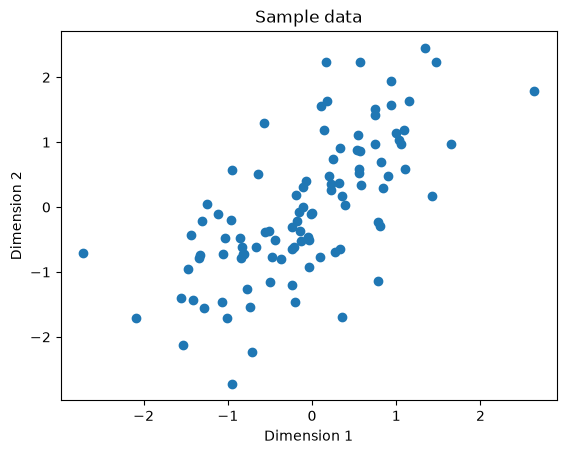

In [179]:
nr.seed(124)
cov = np.array([[1.0, 0.6], [0.6, 1.0]])
mean = np.array([0.0, 0.0])

sample = nr.multivariate_normal(mean, cov, 100)

print(sample)
plt.scatter(sample[:,0], sample[:,1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Sample data')

The sampled values are form a generally eliptical cluster. The shape of this elipse reflects the covariance structure.      

Next, we compute and display the covariance of these data.   

In [180]:
## Compute the covariance 
cov_sample = (1.0/len(sample)) * np.dot(np.transpose(sample), sample)
cov_sample

array([[0.81009834, 0.65727921],
       [0.65727921, 1.16625806]])

Notice that the covariance matrix is square and we can compute the eigen-decomposition. The code in the cell below computes the eigen-decomposition, displays the results, and computes and prints the condition number.            

In [181]:
## Eigendecomposition of covariance  
sample_eigs, sample_Q = np.linalg.eig(cov_sample)
print(sample_eigs)
print('\n')
print(sample_Q)
print('\nThe condition number = {0:6.3}'.format(np.max(sample_eigs)/np.min(sample_eigs)))

[0.30720214+0.j 1.66915426+0.j]


[[-0.79419984+0.j -0.60765665+0.j]
 [ 0.60765665+0.j -0.79419984+0.j]]

The condition number = (5.43+0j)


The matrix appears to be well conditioned.    

We can reconstruct the convaiance matrix from the eigendecomposition using the code below. 

In [182]:
## Reconstruct the covariance matrix   
np.dot(sample_Q, np.dot(np.diag(sample_eigs), np.transpose(sample_Q)))

array([[0.81009834+0.j, 0.65727921+0.j],
       [0.65727921+0.j, 1.16625806+0.j]])

Given the low condition number, we can easily compute the inverse of the covariance matrix. The code in the cell below computes and displays the inverse eigenvalues and the inverse covariance matrix. Finally the inverse is tested to ensure the product of the inverse with the original covariance is an identity matrix.   

In [183]:
## Find and test the inverse   
inv_B_eigs = np.linalg.inv(np.diag(sample_eigs))
print(inv_B_eigs)
print('\nInverse Convariance matrix')
inv_covariance = np.dot(sample_Q,(np.dot(inv_B_eigs, np.transpose(sample_Q))))
print(inv_covariance)
print('\nProduct of inverse and covariance matrix')
print(np.dot(inv_covariance, cov_sample))

[[3.25518569+0.j 0.        +0.j]
 [0.        +0.j 0.5991058 +0.j]]

Inverse Convariance matrix
[[ 2.2744372 +0.j -1.28182633+0.j]
 [-1.28182633+0.j  1.57985429+0.j]]

Product of inverse and covariance matrix
[[ 1.00000000e+00+0.j -4.04486849e-17+0.j]
 [ 1.61271075e-16+0.j  1.00000000e+00+0.j]]


The inverse for the covariance matrix is well determined.    

> **Exercise 02-10:** You will now try an example with highly colinear feature values. The code in the cell below generates multivariate Normally distributed samples with a high dependency between the variables. Execute the code in the cell below.          

In [ ]:
## Increase colinearity of variables 
nr.seed(124)
cov = np.array([[1.0, 0.997], [0.997, 1.0]])
mean = np.array([0.0, 0.0])

sample2 = nr.multivariate_normal(mean, cov, 100)

plt.scatter(sample2[:,0], sample2[:,1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Sample data')

> In the cell below create and execute code to do the following:     
> 1. Compute the covariance matrix of this second data sample.    
> 2. Compute and display the eigen-decomposition of the covariance matrix.   
> 3. Compute and display the condition number.   

In [ ]:
## Put your code below  
## Compute covariance and eigendecompositon   
cov_sample2 = (1.0/len(sample2)) * np.dot(np.transpose(sample2), sample2)/4
cov_sample2
print('\n')
sample2_eigs, sample2_Q = np.linalg.eig(cov_sample2)
print(sample2_eigs)
print('\n')
print(sample2_Q)
print('\nThe condition number = {0:6.3}'.format(sample2_eigs[1]/sample2_eigs[0]))

> In the cell below create and execute code to do the following:      
> 4. Compute and display the inverse eigenvalues.     
> 5. Compute and display the inverse covariance matrix.  
> 6. Compute and display the product of the inverse covariance matrix and the original covariance matrix.  

In [ ]:
## Put your code below   
## Find and test the inverse   
inv_B_eigs2 = np.linalg.inv(np.diag(sample2_eigs))
print(inv_B_eigs2)
print('\nInverse Convariance matrix')
inv_covariance2 = np.dot(sample2_Q,(np.dot(inv_B_eigs2, np.transpose(sample2_Q))))
print(inv_covariance2)
print('\nProduct of inverse and covariance matrix')
print(np.dot(inv_covariance2, cov_sample2))

> Answer the following questions:    
> 1. How does the condition number of the new sample compare to the first one?      
> 2. Is the inverse of this matrix well-determined and why?   

> **Answers:**    
> 1.         
> 2.     

## Singlular Value Decomposition (SVD)  

So far, we have worked with eigen-decomposition which only work for square matricies, such as the covariance matricies. Therefore in principle, you can therefore decompose a rectangular data matrix by computing the covariance matrix first. But, there is a direct, but approximate, method which can be applied to rectangualar matrices, **singular value decomposition** or **SVD**.  

The singular value decomposition of an $n \times p$ matrix $A$ is written:      

\begin{align}     
A &\simeq U S V \\  
Where: & \\
U &= n \times p\ orthonormal\ left\ singular\ vectors\\
S &= p \times p\ diagonal\ matrix\ of\ singular\ values\\ 
V &= p \times p\ orthonormal\ right\ singular\ vectors
\end{align}

Consider a simple example of the SVD decomposition of $n \times p$ data matrix, $A$. The SVD is shown below. Pay particular attention to the dimensions of the arrays required to make the matrix product conformable.       

\begin{align}   
\begin{bmatrix}
   a_{1,1} & a_{1,2}\\
   a_{2,1} & a_{2,2}\\
   a_{3,1} & a_{3,2}\\
   a_{4,1} & a_{4,2}
   \end{bmatrix}
 =
\begin{bmatrix}
   u_{1,1} & u_{1,2}\\
   u_{2,1} & u_{2,2}\\
   u_{3,1} & u_{3,2}\\
   u_{4,1} & u_{4,2}
   \end{bmatrix}
\begin{bmatrix}
   s_1 & 0  \\
   0 & s_2 
   \end{bmatrix}  
\begin{bmatrix}
   v_{1,1} & v_{2,1}\\
   a_{1,2} & a_{2,2}
   \end{bmatrix}  
\end{align}


The code in the cell below uses the [numpy.linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) function to compute the SVD of the sample data and returns the components.  

In [ ]:
## SVD decomposition of sample  
U, S, V = np.linalg.svd(sample2)
U = U[:,:2]
print('U')
print(U)
print('Dimensions of U = ' + str(U.shape))
print('\nS')
print(np.diag(S))
print('\nV')
print(V)

> **Exercise 02-11:** As already discussed, the SVD is only an approximation. You will now determine how good the approximation is in this case. To determine how good the approximation is, do the following:     
> 1. Compute the reconstructed data matrix using the formula given above.     
> 2. Print the dimensions of the reconstructed matrix.   
> 3. Compute and display the Euclidean norm of the difference between the original data matrix and the reconstructed matrix.    

In [ ]:
## Put your code below   





Finally, we can use the SVD to find an approximate inverse of the data matrix in the form shown here:       

$$A^{-1} = V S^{-1} U$$  

The code in the cell below computes and tests the approximation of the inverse.

In [ ]:
## Test inverse of decompostion
S_inverse = np.diag(1.0 / S)
sample2_svd_inverse = np.dot(V, np.dot(S_inverse, np.transpose(U)))
np.dot(sample2_svd_inverse, sample2)

#### Copyright 2020, 2021, 2022, 2023, Stephen F Elston. All rights reserved.